Mounting GOOGLE Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Feature Extraction

In [ ]:
import os
import pickle

import numpy as np
from tqdm import tqdm
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

base_model = InceptionV3(weights='imagenet')
feature_extractor = Model(
    inputs=base_model.input,
    outputs=base_model.layers[-2].output
)

def extract(directory=r"/content/drive/MyDrive/archive/Images", output_path='/content/drive/MyDrive/ColabNotebooks/features.pkl'):
    if not os.path.exists(directory):
        print(f"Directory '{directory}' not found.")
        return

    image_files = [
        f for f in os.listdir(directory)
        if os.path.splitext(f)[1].lower() in IMAGE_EXTS
    ]

    if not image_files:
        print(f"No image files found in '{directory}'.")
        return

    print(f"\nFound {len(image_files)} images. Extracting features...\n")
    features = {}

    for img_name in tqdm(image_files, desc='Extracting'):
        img_path = os.path.join(directory, img_name)
        try:
            image = load_img(img_path, target_size=(299, 299))
            image = img_to_array(image)
            image = np.expand_dims(image, axis=0)
            image = preprocess_input(image)
            feature = feature_extractor.predict(image, verbose=0)
            img_id = os.path.splitext(img_name)[0]
            features[img_id] = feature[0]
        except Exception as e:
            print(f"\nSkipping '{img_name}': {e}")

    pickle.dump(features, open(output_path, 'wb'))
    print(f"\n {len(features)} feature vectors saved → '{output_path}'")

extract()

96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Found 8104 images. Extracting features...



Extracting: 100%|██████████| 8104/8104 [18:41<00:00,  7.23it/s]



 8104 feature vectors saved → '/content/drive/MyDrive/ColabNotebooks/features.pkl'


Tokenization

In [ ]:
import os
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer

SAVE_DIR = '/content/drive/MyDrive/ColabNotebooks/'


def clean_text(captions_path='/content/drive/MyDrive/captions.txt'):
    if not os.path.exists(captions_path):
        print(f"'{captions_path}' not found.")
        return

    mapping = {}
    with open(captions_path, 'r', encoding='utf-8') as f:
        next(f)
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(',', 1)
            if len(parts) < 2:
                continue
            img_id = parts[0].split('.')[0].split('#')[0]
            caption = parts[1].lower().strip()
            if img_id not in mapping:
                mapping[img_id] = []
            mapping[img_id].append(f"startseq {caption} endseq")

    if not mapping:
        print("No captions parsed.")
        return

    all_captions = [cap for caps in mapping.values() for cap in caps]
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(all_captions)
    max_length = max(len(cap.split()) for cap in all_captions)

    pickle.dump(tokenizer, open(SAVE_DIR + 'tokenizer.pkl', 'wb'))
    pickle.dump(mapping, open(SAVE_DIR + 'mapping.pkl',   'wb'))
    with open(SAVE_DIR + 'max_length.txt', 'w') as f:
        f.write(str(max_length))

    vocab_size = len(tokenizer.word_index) + 1
    print(f"tokenizer.pkl vocab = {vocab_size} words")
    print(f"mapping.pkl {len(mapping)} images")
    print(f"max_length.txt {max_length}")

clean_text()

tokenizer.pkl  → vocab = 8496 words
mapping.pkl    → 8091 images
max_length.txt → 40
All saved to   → /content/drive/MyDrive/ColabNotebooks/


Model Training

In [ ]:
import gc, os, random, pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, Embedding, Input, LSTM, add
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences

SAVE_DIR = '/content/drive/MyDrive/ColabNotebooks/'
CHECKPOINT_PATH = SAVE_DIR + 'vision_voice_model.keras'


features = pickle.load(open(SAVE_DIR + 'features.pkl',  'rb'))
tokenizer = pickle.load(open(SAVE_DIR + 'tokenizer.pkl', 'rb'))
mapping = pickle.load(open(SAVE_DIR + 'mapping.pkl',   'rb'))

with open(SAVE_DIR + 'max_length.txt', 'r') as f:
    max_length = int(f.read().strip())

vocab_size = len(tokenizer.word_index) + 1

print(f"Vocab size : {vocab_size}")
print(f"Max length : {max_length}")
print(f"Images : {len(mapping)}")
print(f"Features : {len(features)}")


def data_generator(mapping, features, tokenizer, max_length, vocab_size, batch_size):
    keys = list(mapping.keys())
    while True:
        random.shuffle(keys)
        for i in range(0, len(keys), batch_size):
            X1, X2, y = [], [], []
            for key in keys[i:i + batch_size]:
                if key not in features:
                    continue
                feature = features[key].astype(np.float32)
                for caption in mapping[key]:
                    seq = tokenizer.texts_to_sequences([caption])[0]
                    for j in range(1, len(seq)):
                        in_seq = pad_sequences([seq[:j]], maxlen=max_length, padding='post')[0].astype(np.int32)
                        X1.append(feature)
                        X2.append(in_seq)
                        y.append(seq[j])
            if not X1:
                continue
            yield (
                np.array(X1, dtype=np.float32),
                np.array(X2, dtype=np.int32)
            ), np.array(y, dtype=np.int32)
            del X1, X2, y
            gc.collect()
if os.path.exists(CHECKPOINT_PATH):
    model = load_model(CHECKPOINT_PATH)
else:
  inputs1  = Input(shape=(2048,), name='image_input')
  fe1 = Dropout(0.5)(inputs1)
  fe2 = Dense(512, activation='relu', name='image_dense')(fe1)

  inputs2  = Input(shape=(max_length,), name='sequence_input')
  se1 = Embedding(vocab_size, 512, mask_zero=False, name='embedding')(inputs2)
  se2 = Dropout(0.5)(se1)
  se3 = LSTM(512, name='lstm', use_cudnn=False)(se2)

  decoder1 = add([fe2, se3])
  decoder2 = Dense(512, activation='relu')(decoder1)
  outputs = Dense(vocab_size, activation='softmax')(decoder2)

  model = Model(inputs=[inputs1, inputs2], outputs=outputs)
  model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
model.summary()


callbacks = [
    ModelCheckpoint(
        CHECKPOINT_PATH,
        monitor='loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    EarlyStopping(
        monitor='loss',
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
]

BATCH_SIZE = 64
EPOCHS = 30
steps = max(1, len(mapping) // BATCH_SIZE)

print(f" Vocab: {vocab_size} words")
print(f" Neurons: 512")
print(f" Epochs: {EPOCHS}")
print(f" Batch size: {BATCH_SIZE}")
print(f" Steps/epoch: {steps}")
print(f" Target loss: below 2.0\n")

with tf.device('/GPU:0'):
  model.fit(
      data_generator(mapping, features, tokenizer, max_length, vocab_size, BATCH_SIZE),
      steps_per_epoch=steps,
      epochs=EPOCHS,
      verbose=1,
      initial_epoch=19,
      callbacks=callbacks,
  )

Vocab size : 8496
Max length : 40
Images : 8091
Features : 8104


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 40, 512)   │  4,349,952 │ sequence_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 40, 512)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_dense (Dense) │ (None, 512)       │  1,049,088 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 512)       │  2,099,200 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 512)       │          0 │ image_dense[0][0… │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    262,656 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8496)      │  4,358,448 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 36,358,034 (138.69 MB)

 Trainable params: 12,119,344 (46.23 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 24,238,690 (92.46 MB)

 Vocab: 8496 words
 Neurons: 512
 Epochs: 30
 Batch size: 64
 Steps/epoch: 126
 Target loss: below 2.0

Epoch 20/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 756ms/step - loss: 2.0123
Epoch 20: loss improved from None to 2.06142, saving model to /content/drive/MyDrive/ColabNotebooks/vision_voice_model.keras

Epoch 20: finished saving model to /content/drive/MyDrive/ColabNotebooks/vision_voice_model.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 97s 762ms/step - loss: 2.0614 - learning_rate: 0.0010
Epoch 21/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 758ms/step - loss: 2.0225
Epoch 21: loss improved from 2.06142 to 2.04113, saving model to /content/drive/MyDrive/ColabNotebooks/vision_voice_model.keras

Epoch 21: finished saving model to /content/drive/MyDrive/ColabNotebooks/vision_voice_model.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 96s 764ms/step - loss: 2.0411 - learning_rate: 0.0010
Epoch 22/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 781ms/step - loss: 1.9881
Epoch 22: loss improved from 2.04113 to 2.00666, saving model to /con

In [12]:
from gtts import gTTS
from IPython.display import Audio, display
import os

def speak_caption(caption):
    clean = caption.replace('startseq', '').replace('endseq', '').strip()
    if not clean:
        print("Caption is empty")
        return
    print(f"VisionVoice is saying: {clean}")
    tts = gTTS(text=clean, lang='en', slow=False)
    tts.save('/content/caption_audio.mp3')
    display(Audio('/content/caption_audio.mp3', autoplay=True))


VisionVoice is saying: a man in a helmet riding a bike


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/trainer.py:212: UserWarning: Model doesn't support `jit_compile=True`. Proceeding with `jit_compile=False`.
  warnings.warn(


Model loaded!
Vocab size : 8496
Max length : 40
Feature extractor ready!
Upload an image...


Saving 307327914_f98f576adb.jpg to 307327914_f98f576adb.jpg

AI is analysing the scene...

Generated Caption: a man with glasses and a mustache is smiling

VisionVoice is saying: a man with glasses and a mustache is smiling


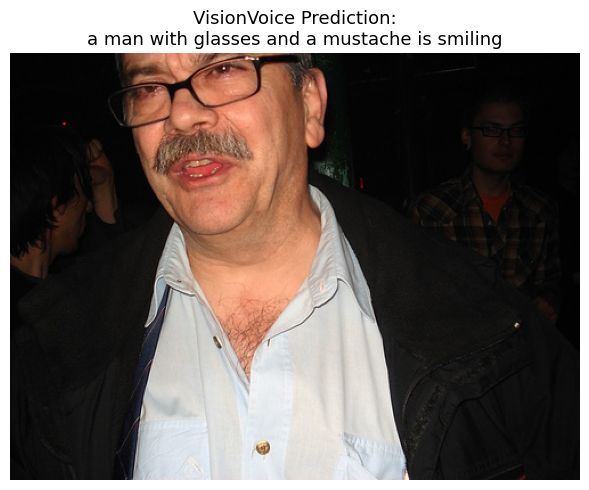

In [14]:
import gc, os, random, pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from google.colab import files
from IPython.display import display, Image as IPImage
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt

SAVE_DIR = '/content/drive/MyDrive/ColabNotebooks/'

try:
    demo_model = load_model(SAVE_DIR + 'vision_voice_model.keras')
except Exception:
    demo_model = load_model(SAVE_DIR + 'vision_voice_model.keras',
                            custom_objects={"NotEqual": tf.math.not_equal},
                            compile=False)
print("Model loaded!")

demo_tokenizer = pickle.load(open(SAVE_DIR + 'tokenizer.pkl', 'rb'))
with open(SAVE_DIR + 'max_length.txt', 'r') as f:
    demo_max_length = int(f.read().strip())

print(f"Vocab size : {len(demo_tokenizer.word_index) + 1}")
print(f"Max length : {demo_max_length}")

iv3_base = InceptionV3(weights='imagenet')
demo_feat_mdl = Model(inputs=iv3_base.input, outputs=iv3_base.layers[-2].output)
print("Feature extractor ready!")

def predict_caption(image_path):
    img = load_img(image_path, target_size=(299, 299))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    feature = demo_feat_mdl.predict(img, verbose=0)
    in_text = 'startseq'
    for _ in range(demo_max_length):
        sequence = demo_tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=demo_max_length, padding='post')
        yhat = demo_model.predict([feature, sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = next(
            (w for w, idx in demo_tokenizer.word_index.items() if idx == yhat),
            None
        )
        if word is None or word == 'endseq':
            break
        in_text += ' ' + word
    return in_text.replace('startseq', '').strip()

def run_demo_colab():
    print("Upload an image...")
    uploaded = files.upload()
    img_filename = list(uploaded.keys())[0]
    img_path = f"/content/{img_filename}"

    print("\nAI is analysing the scene...")
    clean_caption = predict_caption(img_path)
    print(f"\nGenerated Caption: {clean_caption}\n")

    speak_caption(clean_caption)
    plt.figure(figsize=(7, 5))
    plt.imshow(load_img(img_path))
    plt.title(f"VisionVoice Prediction:\n{clean_caption}", fontsize=13)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

run_demo_colab()

Vocab size : 8496
Max length : 40
Images : 8091


/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


50


/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


100
150
200
Evaluation complete!
VisionVoice — Validation Report

Images evaluated: 200

BLEU-1: 74.14%  (word accuracy)
BLEU-2 : 60.50%  (2-word phrases)
BLEU-3 : 47.48%  (3-word phrases)
BLEU-4 : 36.30%  (sentence fluency)

Avg BLEU-1/image : 70.80%
Avg BLEU-2/image : 56.87%


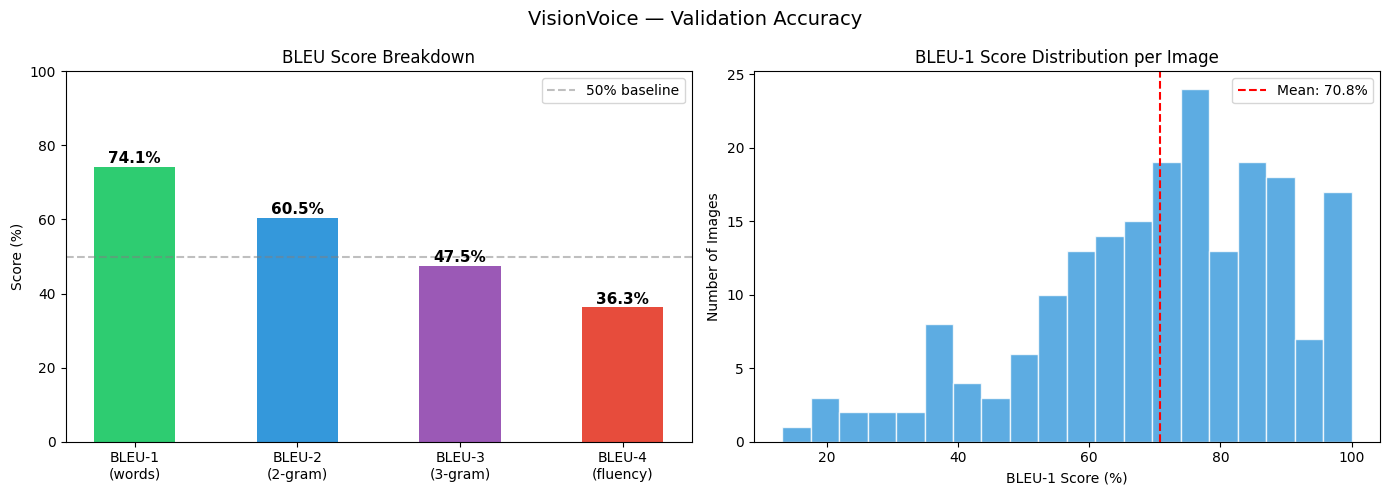

Sample Predictions

[1] Image: 1000268201_693b08cb0e
Predicted : a child in a blue dress going down a wooden stairs
Actual: a child in a pink dress is climbing up a set of stairs in an entry way .

[2] Image: 1001773457_577c3a7d70
Predicted : two dogs playing with each other on the sand
Actual: a black dog and a spotted dog are fighting

[3] Image: 1002674143_1b742ab4b8
Predicted : a girl is jumping in front of a small rainbow
Actual: a little girl covered in paint sits in front of a painted rainbow with her hands in a bowl .

[4] Image: 1003163366_44323f5815
Predicted : a man lays on a bench with his feet on a white dog
Actual: a man lays on a bench while his dog sits by him .

[5] Image: 1007129816_e794419615
Predicted : a man with gauges and a beard with gauges on his head
Actual: a man in an orange hat starring at something .


In [ ]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.sequence import pad_sequences
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import nltk
nltk.download('punkt', quiet=True)

SAVE_DIR = '/content/drive/MyDrive/ColabNotebooks/'

demo_tokenizer = pickle.load(open(SAVE_DIR + 'tokenizer.pkl', 'rb'))
mapping = pickle.load(open(SAVE_DIR + 'mapping.pkl',   'rb'))
features = pickle.load(open(SAVE_DIR + 'features.pkl',  'rb'))

with open(SAVE_DIR + 'max_length.txt', 'r') as f:
    demo_max_length = int(f.read().strip())

print(f"Vocab size : {len(demo_tokenizer.word_index) + 1}")
print(f"Max length : {demo_max_length}")
print(f"Images : {len(mapping)}")

def generate_caption(feature):
    in_text = 'startseq'
    for _ in range(demo_max_length):
        seq = demo_tokenizer.texts_to_sequences([in_text])[0]
        seq = pad_sequences([seq], maxlen=demo_max_length, padding='post')
        yhat = demo_model.predict([feature.reshape(1, -1), seq], verbose=0)
        yhat = np.argmax(yhat)
        word = next(
            (w for w, idx in demo_tokenizer.word_index.items() if idx == yhat),
            None
        )
        if word is None or word == 'endseq':
            break
        in_text += ' ' + word
    return in_text.replace('startseq', '').strip()


EVAL_SAMPLE = 200
common_keys = [k for k in mapping.keys() if k in features]
eval_keys = common_keys[:EVAL_SAMPLE]

actual_corpus = []
predicted_corpus = []
bleu1_scores = []
bleu2_scores = []
smoothing = SmoothingFunction().method1

for i, key in enumerate(eval_keys):
    feature = features[key]
    predicted = generate_caption(feature)

    references = []
    for cap in mapping[key]:
        clean = cap.replace('startseq','').replace('endseq','').strip()
        references.append(clean.split())

    predicted_tokens = predicted.split()
    actual_corpus.append(references)
    predicted_corpus.append(predicted_tokens)

    b1 = corpus_bleu([references], [predicted_tokens], weights=(1,0,0,0))
    b2 = corpus_bleu([references], [predicted_tokens], weights=(0.5,0.5,0,0))
    bleu1_scores.append(b1)
    bleu2_scores.append(b2)

    if (i+1) % 50 == 0:
        print(f"{i+1}")

print("Evaluation complete!")

bleu1 = corpus_bleu(actual_corpus, predicted_corpus, weights=(1.0, 0, 0, 0))
bleu2 = corpus_bleu(actual_corpus, predicted_corpus, weights=(0.5, 0.5, 0, 0))
bleu3 = corpus_bleu(actual_corpus, predicted_corpus, weights=(0.33, 0.33, 0.33, 0))
bleu4 = corpus_bleu(actual_corpus, predicted_corpus, weights=(0.25, 0.25, 0.25, 0.25))

print("VisionVoice — Validation Report")

print(f"\nImages evaluated: {len(eval_keys)}")
print(f"\nBLEU-1: {bleu1*100:.2f}%  (word accuracy)")
print(f"BLEU-2 : {bleu2*100:.2f}%  (2-word phrases)")
print(f"BLEU-3 : {bleu3*100:.2f}%  (3-word phrases)")
print(f"BLEU-4 : {bleu4*100:.2f}%  (sentence fluency)")
print(f"\nAvg BLEU-1/image : {np.mean(bleu1_scores)*100:.2f}%")
print(f"Avg BLEU-2/image : {np.mean(bleu2_scores)*100:.2f}%")



fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('VisionVoice — Validation Accuracy', fontsize=14)

scores = [bleu1*100, bleu2*100, bleu3*100, bleu4*100]
labels = ['BLEU-1\n(words)', 'BLEU-2\n(2-gram)', 'BLEU-3\n(3-gram)', 'BLEU-4\n(fluency)']
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

bars = axes[0].bar(labels, scores, color=colors, width=0.5)
axes[0].set_title('BLEU Score Breakdown')
axes[0].set_ylabel('Score (%)')
axes[0].set_ylim(0, 100)
axes[0].axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='50% baseline')
for bar, score in zip(bars, scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{score:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].legend()

axes[1].hist(np.array(bleu1_scores)*100, bins=20, color='#3498db', edgecolor='white', alpha=0.8)
axes[1].axvline(x=np.mean(bleu1_scores)*100, color='red', linestyle='--', label=f'Mean: {np.mean(bleu1_scores)*100:.1f}%')
axes[1].set_title('BLEU-1 Score Distribution per Image')
axes[1].set_xlabel('BLEU-1 Score (%)')
axes[1].set_ylabel('Number of Images')
axes[1].legend()

plt.tight_layout()
plt.savefig(SAVE_DIR + 'validation_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("Sample Predictions")

for i, key in enumerate(eval_keys[:5], 1):
    predicted = generate_caption(features[key])
    actual = mapping[key][0].replace('startseq','').replace('endseq','').strip()
    print(f"\n[{i}] Image: {key}")
    print(f"Predicted : {predicted}")
    print(f"Actual: {actual}")